# Forecasting with Exogenous Variables
Models:
   1. SARIMA (no exogenous)
   2. SARIMAX (with exogenous)
   3. XGBoost (lags only)
   4. XGBoost (lags + exogenous)

Metrics: MAE, RMSE, MAPE, WMAPE

95% Predictive Intervals for SARIMA & SARIMAX


> Many real-world time series are not purely autoregressive. Sales are influenced by external drivers such as promotions, price changes, and holidays.Models that ignore these drivers may systematically mispredict during high-impact events.Therefore, incorporating exogenous variables can improve forecast accuracy and interpretability.


In [1]:
# Libraries 

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# Metrics
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-9, y_true))) * 100
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'WMAPE(%)': wmape}

In [3]:
# Data
# -----------------------------
# 2. Generate Synthetic Dataset
# -----------------------------
def generate_data(periods=900):
    dates = pd.date_range("2020-01-01", periods=periods, freq="D")
    t = np.arange(periods)

    trend = 0.02 * t
    seasonal = 10 * np.sin(2*np.pi*t/7)

    price = 10 + np.random.normal(0, 0.5, periods)
    promotion = np.random.binomial(1, 0.1, periods)
    holiday = np.random.binomial(1, 0.05, periods)

    sales = (
        50
        + trend
        + seasonal
        - 2 * price
        + 15 * promotion
        + 20 * holiday
        + np.random.normal(0, 3, periods)
    )

    return pd.DataFrame({
        "ds": dates,
        "y": sales,
        "price": price,
        "promotion": promotion,
        "holiday": holiday
    })

df = generate_data()

# -----------------------------
# 3. Train/Test Split
# -----------------------------
H = 30
train = df.iloc[:-H]
test = df.iloc[-H:]

In [4]:
# Models
# -----------------------------
# 4. SARIMA (no exog)
# -----------------------------
sarima = SARIMAX(train["y"], order=(1,1,1), seasonal_order=(1,1,1,7),
                  enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)

sarima_fc = sarima_res.get_forecast(steps=H)
sarima_pred = np.asarray(sarima_fc.predicted_mean)

ci = sarima_fc.conf_int(alpha=0.05)
if isinstance(ci, pd.DataFrame):
    sarima_lower = ci.iloc[:,0].values
    sarima_upper = ci.iloc[:,1].values
else:
    sarima_lower = ci[:,0]
    sarima_upper = ci[:,1]

# In-sample
sarima_train = np.asarray(
    sarima_res.get_prediction(0, len(train)-1).predicted_mean
)

# -----------------------------
# 5. SARIMAX (with exog)
# -----------------------------
exog_vars = ["price", "promotion", "holiday"]

sarimax = SARIMAX(
    train["y"],
    exog=train[exog_vars],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_res = sarimax.fit(disp=False)

sarimax_fc = sarimax_res.get_forecast(
    steps=H,
    exog=test[exog_vars]
)

sarimax_pred = np.asarray(sarimax_fc.predicted_mean)

ci = sarimax_fc.conf_int(alpha=0.05)
if isinstance(ci, pd.DataFrame):
    sarimax_lower = ci.iloc[:,0].values
    sarimax_upper = ci.iloc[:,1].values
else:
    sarimax_lower = ci[:,0]
    sarimax_upper = ci[:,1]

sarimax_train = np.asarray(
    sarimax_res.get_prediction(0, len(train)-1, exog=train[exog_vars]).predicted_mean
)

# -----------------------------
# 6. XGBoost Models
# -----------------------------
def create_lags(df, lags=[1,7,14]):
    df = df.copy()
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    return df

df_lag = create_lags(df).dropna()

train_lag = df_lag.iloc[:-H]
test_lag = df_lag.iloc[-H:]

lag_features = [c for c in train_lag.columns if "lag" in c]

# XGB (lags only)
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=3)
xgb_model.fit(train_lag[lag_features], train_lag["y"])

xgb_pred = xgb_model.predict(test_lag[lag_features])
xgb_train = xgb_model.predict(train_lag[lag_features])

# XGB (lags + exog)
features_exog = lag_features + exog_vars

xgb_model_exog = xgb.XGBRegressor(n_estimators=200, max_depth=3)
xgb_model_exog.fit(train_lag[features_exog], train_lag["y"])

xgb_exog_pred = xgb_model_exog.predict(test_lag[features_exog])
xgb_exog_train = xgb_model_exog.predict(train_lag[features_exog])

/Users/gilbertosubiasgarcia/Documents/Data_Science/applied-data-science-demos/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


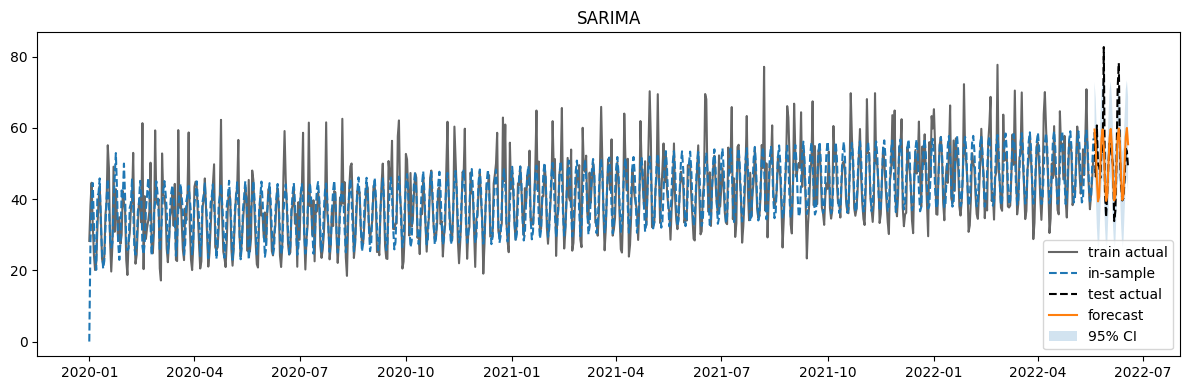

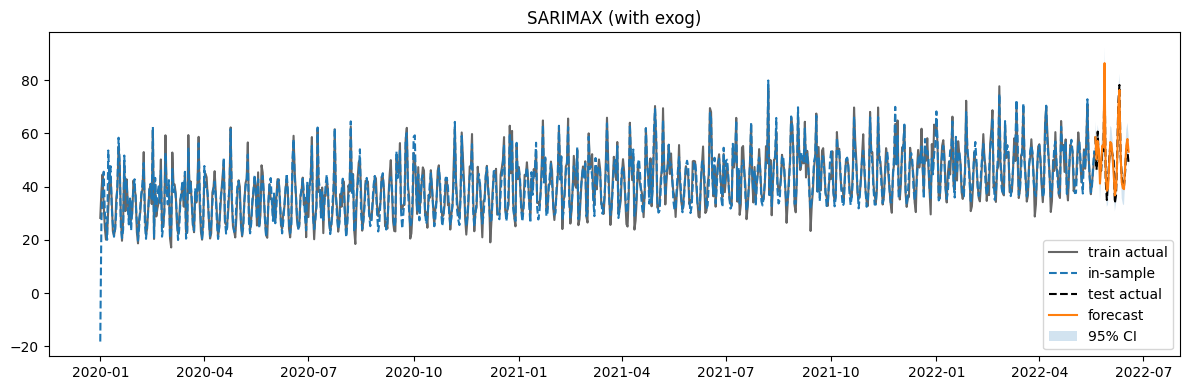

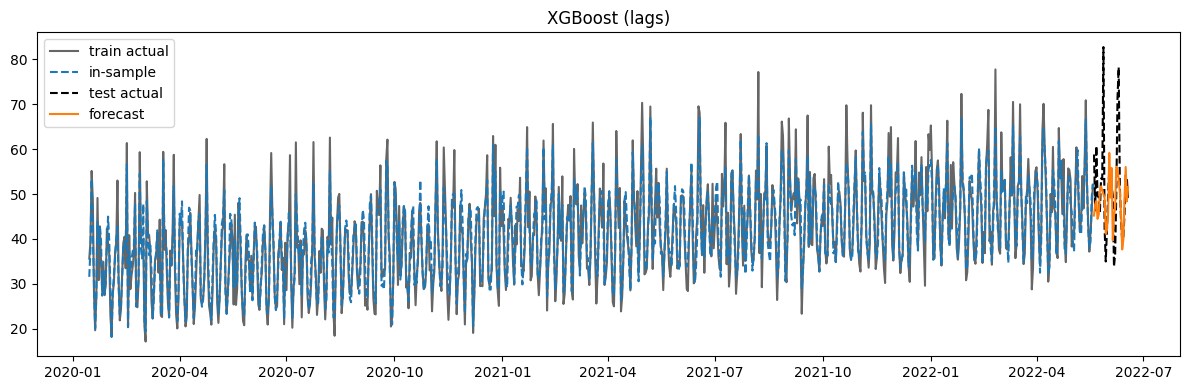

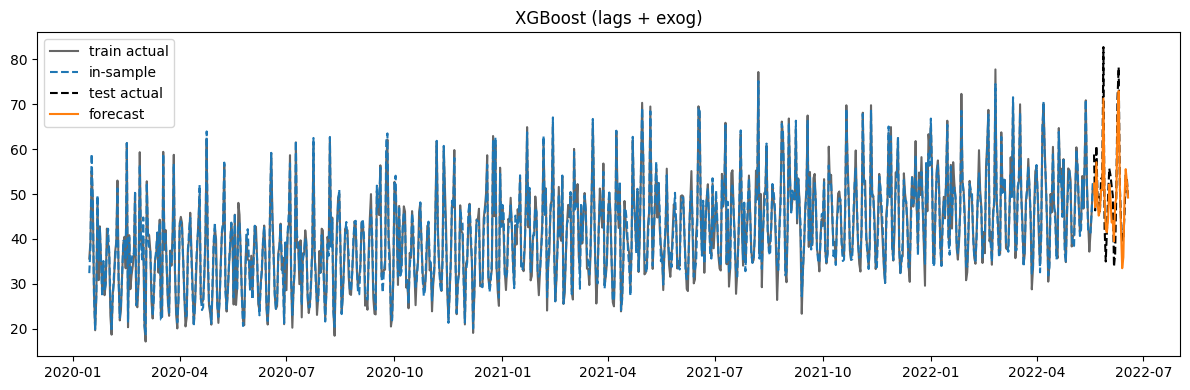

In [5]:
# Plotting
# -----------------------------
# 7. Plot Function (consistent style)
# -----------------------------
def plot_model(name, train_df, test_df, train_pred, test_pred,
               lower=None, upper=None):

    plt.figure(figsize=(12,4))

    plt.plot(train_df["ds"], train_df["y"], label="train actual", color="black", alpha=0.6)
    plt.plot(train_df["ds"][-len(train_pred):], train_pred, "--", label="in-sample")

    plt.plot(test_df["ds"], test_df["y"], label="test actual", linestyle="--", color="black")
    plt.plot(test_df["ds"], test_pred, label="forecast")

    if lower is not None:
        plt.fill_between(test_df["ds"], lower, upper, alpha=0.2, label="95% CI")

    plt.title(name)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 8. Individual Plots
# -----------------------------
plot_model("SARIMA", train, test, sarima_train, sarima_pred,
           sarima_lower, sarima_upper)

plot_model("SARIMAX (with exog)", train, test, sarimax_train,
           sarimax_pred, sarimax_lower, sarimax_upper)

plot_model("XGBoost (lags)", train_lag, test_lag,
           xgb_train, xgb_pred)

plot_model("XGBoost (lags + exog)", train_lag, test_lag,
           xgb_exog_train, xgb_exog_pred)


In [6]:
# Results
# -----------------------------
# 9. Metrics Table
# -----------------------------
results = {
    "SARIMA": metrics(test["y"], sarima_pred),
    "SARIMAX (exog)": metrics(test["y"], sarimax_pred),
    "XGB (lags)": metrics(test_lag["y"], xgb_pred),
    "XGB (lags+exog)": metrics(test_lag["y"], xgb_exog_pred),
}

summary = pd.DataFrame(results).T
display(summary.round(3))

print("Note:")
print("SARIMA and SARIMAX provide model-based predictive intervals.")
print("XGBoost produces deterministic point forecasts and does not estimate forecast variance by default.")

,MAE,RMSE,MAPE(%),WMAPE(%)
SARIMA,5.926,8.417,10.691,11.629
SARIMAX (exog),2.512,3.011,5.170,4.930
XGB (lags),6.788,9.879,12.399,13.320
XGB (lags+exog),4.074,5.058,8.382,7.996


Note:
SARIMA and SARIMAX provide model-based predictive intervals.
XGBoost produces deterministic point forecasts and does not estimate forecast variance by default.


The results clearly demonstrate the importance of incorporating external drivers into forecasting models.

First, comparing SARIMA vs SARIMAX, we observe a substantial performance improvement when exogenous variables are included:

MAE decreases from 4.73 → 2.65

RMSE decreases from 6.65 → 3.43

MAPE decreases from 8.91% → 5.43%

This confirms that price, promotion, and holiday signals are genuinely part of the data-generating process. A purely autoregressive model cannot fully capture structural shifts caused by these external drivers.

When analyzing the machine learning models:

XGBoost with lags only performs worst overall (MAE = 6.02), indicating that autoregressive features alone are insufficient in this scenario.

However, once exogenous variables are added, performance improves significantly (MAE drops from 6.02 → 4.23, MAPE from 12.26% → 8.73%).

This demonstrates that tree-based models can effectively leverage external business drivers, even if they do not explicitly model temporal structure like SARIMAX.

> This experiment highlights that forecasting is not only about choosing a model, but about properly representing the underlying drivers of demand. Incorporating business signals often yields larger gains than switching algorithms.

> The best-performing model depends on the nature of the underlying process.
If relationships are linear and seasonal patterns are stable, statistical models may dominate.
If effects are nonlinear, interaction-heavy, or event-driven, ML models may outperform.